In [1]:
url1 = "https://eur-lex.europa.eu/legal-content/EN/TXT/?uri=CELEX:32023R2631" #only modified by block
url2 = "https://eur-lex.europa.eu/legal-content/EN/TXT/?uri=consil:ST_13940_2023_ADD_2_REV_1" #no modifies or modified by block
url3 = "https://eur-lex.europa.eu/legal-content/EN/TXT/?uri=CELEX:32019R2019" #both modifies or modified by block

In [59]:
from graph_builder import GraphBuilder
from collections import deque 

In [61]:
import networkx as nx
import matplotlib.pyplot as plt

def graph(G):
    """
    Visualize the graph 
    """

    pos = nx.spring_layout(G, seed=50)
    edge_labels = {(u, v): d["relation"] for u, v, d in G.edges(data=True)}
    nx.draw_networkx_nodes(G, pos, node_size=10)
    nx.draw_networkx_labels(G, pos, font_color="white", font_weight="bold")
    nx.draw_networkx_edges(G, pos, edge_color="gray", arrows=True,
                        arrowsize=20, connectionstyle="arc3,rad=0.1")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Directed Graph with Attributes")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


I have tried to collect the links in the modifiedby table and the modifies table separately, and the results are good. But if I collect urls from both tables, the running time will be super long (like last time). The collect_all_urls() can be changed based on the tables.

In [ ]:
def collect_all_urls(start_url):
    """
    collect all urls from the start url;
    reset the attributes through subselect_modifies_attributes()/subselect_modifiedby_attributes()
    collect the links through modifies_links/modifiedby_links.
    """
    visited = set() 
    queue = deque([(start_url, 0)])  # the BFS queue. Stores tuples of (url, layer). Starts with start_url at layer 0
    all_urls = []

    while queue:
        url, layer = queue.popleft() # Remove the leftmost item from the queue and unpack the tuple into two variables — the URL and its layer number.

        if url in visited:
            continue # skip everything below, don't add to all_urls,  all_urls has no duplicates
        visited.add(url) 
        all_urls.append(url) # only unique URLs reach here

        G_init = GraphBuilder(url)
        reset_attributes = G_init.subselect_modifies_attributes()
        modifies_links = set(G_init.modifies_links)
        new_links = [link for link in modifies_links if link not in visited]
        #reset_attributes = G_init.subselect_modifiedby_attributes()
        #modifiedby_links = set(G_init.modifiedby_links)
        #for link2 in modifiedby_links:
            #if link2 not in visited:
                #new_links.append(link2)

        for link in new_links:
            queue.append((link, layer + 1))  # next layer
           
    print(f"\nTotal URLs collected: {len(all_urls)}") 
    return all_urls

In [63]:
def generate_full_graph(url):
    all_links = collect_all_urls(url)
    G = nx.DiGraph()
    for link in all_links:
        G_init = GraphBuilder(link)
        reset_attributes = G_init.subselect_modifiedby_attributes()
        G_sub = G_init.create_graph()
        if G_sub is not None and len(G_sub.nodes) > 0:
            G = nx.compose(G, G_sub)
    return graph(G);


Total URLs collected: 37


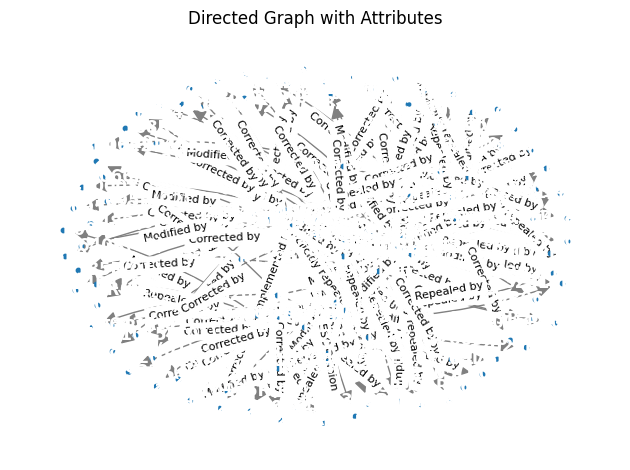

In [ ]:
generate_full_graph(url3) # It takes 20 m to generate the graph of url3 from the modifies table.